# Slack Messages EDA
Exploratory Data Analysis of anonymized Slack messages from Gebeya Batch 6.

## 1. Load Data

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from src.loader import SlackDataLoader
from src.utils import add_time_columns

sns.set_theme(style='whitegrid')

loader = SlackDataLoader()
print('Channels found:', loader.get_channels())

Matplotlib is building the font cache; this may take a moment.


Channels found: ['chang-w11', 'all-week3', 'all-week4', 'adludios-challange', 'all-week5', 'all-technical-support', 'all-week2', 'gokada-challenge-presentation', 'all-ideas', 'all-week11', 'all-week10', 'study-group', 'team-10', 'all-resources', 'week4-teamwork', 'all-ml-week12', 'all-career-exercises', 'data-engineering', 'week-2-group-8', 'all-de-week12', 'batch6_week4_studygroup', 'happy-new-year-study-group', 'all-week9', 'all-week7', 'week-11-group4', 'all-week1', 'all-week6', 'all-week8', 'kafka_de', 'all-week12', 'all-web3-week12', 'random', 'all-community-building', 'tenx-bot', 'machine-learning', 'week2-group', 'all-broadcast', 'ab_test-group', 'dsa-sql']


In [2]:
df = loader.load_all_channels()
print('Total messages:', len(df))
print('Columns:', df.columns.tolist())
df.head()

Total messages: 20011
Columns: ['client_msg_id', 'type', 'text', 'user', 'ts', 'blocks', 'team', 'user_team', 'source_team', 'user_profile', 'attachments', 'channel', 'thread_ts', 'reply_count', 'reply_users_count', 'latest_reply', 'reply_users', 'replies', 'is_locked', 'subscribed', 'parent_user_id', 'reactions', 'edited', 'subtype', 'inviter', 'files', 'upload', 'display_as_bot', 'x_files', 'hidden', 'last_read', 'root', 'room', 'no_notifications', 'permalink', 'bot_id', 'app_id', 'bot_profile', 'bot_link']


,client_msg_id,type,text,user,ts,blocks,team,user_team,source_team,user_profile,...,hidden,last_read,root,room,no_notifications,permalink,bot_id,app_id,bot_profile,bot_link
0,95E2D51C-A202-441E-93EB-575B91711771,message,guys meeting has started,U03V61VGQG0,1667545497.985049,"[{'type': 'rich_text', 'block_id': 'KIeB', 'el...",T03U4J8HMUG,T03U4J8HMUG,T03U4J8HMUG,"{'avatar_hash': '5e18062f5298', 'image_72': 'h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b1babe47-4b11-47cf-b4ec-5bdbfb0b7b02,message,can anyone please explain to me what we are ex...,U03UAKATQ22,1667568314.731399,"[{'type': 'rich_text', 'block_id': 'KQwcp', 'e...",T03U4J8HMUG,T03U4J8HMUG,T03U4J8HMUG,"{'avatar_hash': 'a2d0afeb249a', 'image_72': 'h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,78116b44-69d3-4178-99bf-79595f555e75,message,i think the objective is to predict if the use...,U03UH397319,1667585219.678799,"[{'type': 'rich_text', 'block_id': 'qrC8', 'el...",T03U4J8HMUG,T03U4J8HMUG,T03U4J8HMUG,"{'avatar_hash': 'gc7c2fbea497', 'image_72': 'h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bba6981e-6c69-45a0-ab86-3660af775272,message,that's it based on my understanding,U03UH397319,1667585236.508469,"[{'type': 'rich_text', 'block_id': 'FsPw', 'el...",T03U4J8HMUG,T03U4J8HMUG,T03U4J8HMUG,"{'avatar_hash': 'gc7c2fbea497', 'image_72': 'h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8a7c78d5-cc7a-4a2e-916f-6e39a78a91b5,message,<@u03uakatq22> as you could imagine we are ext...,U03UUN8M4RX,1667631921.620319,"[{'type': 'rich_text', 'block_id': 'e8f9', 'el...",T03U4J8HMUG,T03U4J8HMUG,T03U4J8HMUG,"{'avatar_hash': 'bc5543c34cbf', 'image_72': 'h...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean & Prepare Data

In [3]:
# Keep only real messages (drop channel join/leave events)
df = df[df['type'] == 'message'].copy()
df = df[df['subtype'].isna()].copy() if 'subtype' in df.columns else df

# Fill missing counts with 0
df['reply_count'] = pd.to_numeric(df.get('reply_count', 0), errors='coerce').fillna(0).astype(int)

# Count total reactions per message
df['reaction_count'] = df['reactions'].apply(
    lambda r: sum(x['count'] for x in r) if isinstance(r, list) else 0
)

# Count mentions (<@USERID> pattern) in message text
df['mention_count'] = df['text'].apply(
    lambda t: len(re.findall(r'<@[A-Z0-9]+>', str(t)))
)

# Add time columns
df = add_time_columns(df)

print('Clean messages:', len(df))
df[['user', 'text', 'channel', 'reply_count', 'reaction_count', 'mention_count', 'datetime']].head()

Clean messages: 18945


,user,text,channel,reply_count,reaction_count,mention_count,datetime
0,U03V61VGQG0,guys meeting has started,chang-w11,0,0,0,2022-11-04 07:04:57.985049009
1,U03UAKATQ22,can anyone please explain to me what we are ex...,chang-w11,5,0,0,2022-11-04 13:25:14.731399059
2,U03UH397319,i think the objective is to predict if the use...,chang-w11,0,1,0,2022-11-04 18:06:59.678798914
3,U03UH397319,that's it based on my understanding,chang-w11,0,0,0,2022-11-04 18:07:16.508469105
4,U03UUN8M4RX,<@u03uakatq22> as you could imagine we are ext...,chang-w11,0,0,0,2022-11-05 07:05:21.620318890


## 3. Top & Bottom 10 Users

In [4]:
def plot_top_bottom(df, column, label):
    user_stats = df.groupby('user')[column].sum().reset_index()
    top10 = user_stats.nlargest(10, column)
    bottom10 = user_stats.nsmallest(10, column)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(data=top10, x=column, y='user', ax=axes[0], palette='Blues_r')
    axes[0].set_title(f'Top 10 Users by {label}')

    sns.barplot(data=bottom10, x=column, y='user', ax=axes[1], palette='Reds_r')
    axes[1].set_title(f'Bottom 10 Users by {label}')

    plt.tight_layout()
    plt.show()

/var/folders/9w/mmnsxrnd18bbj_zyw1pcynn40000gn/T/ipykernel_89269/2450042849.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_msg, x='message_count', y='user', ax=axes[0], palette='Blues_r')
/var/folders/9w/mmnsxrnd18bbj_zyw1pcynn40000gn/T/ipykernel_89269/2450042849.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_msg, x='message_count', y='user', ax=axes[1], palette='Reds_r')


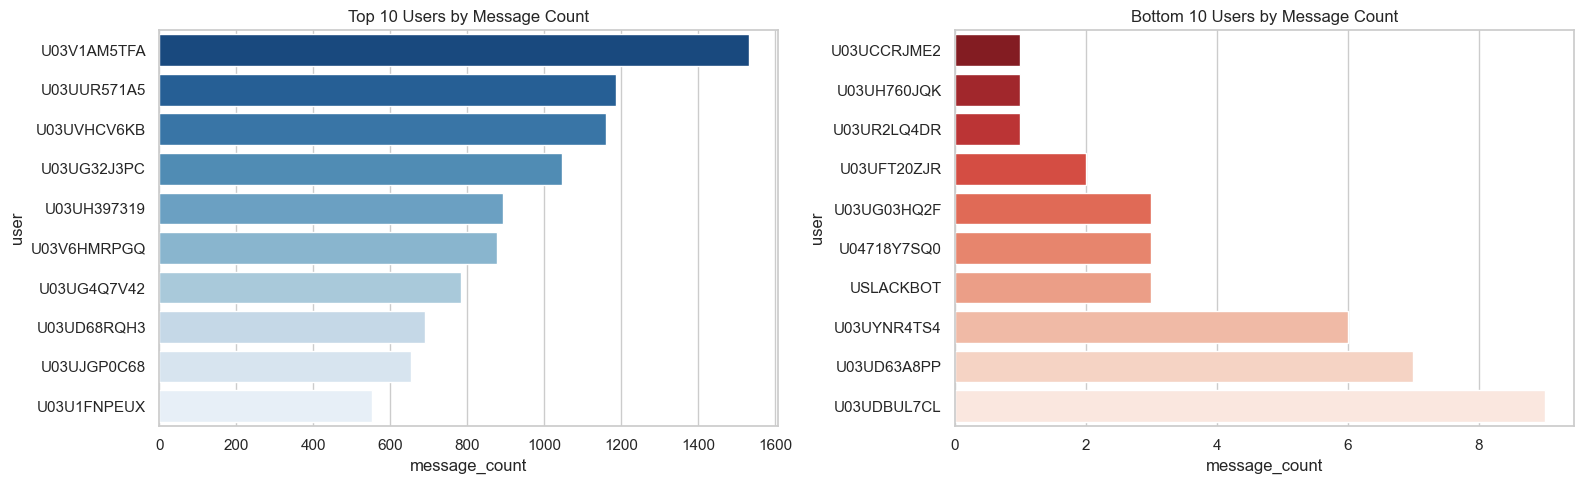

In [5]:
# Message count
msg_count = df.groupby('user').size().reset_index(name='message_count')
top_msg = msg_count.nlargest(10, 'message_count')
bottom_msg = msg_count.nsmallest(10, 'message_count')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=top_msg, x='message_count', y='user', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Users by Message Count')
sns.barplot(data=bottom_msg, x='message_count', y='user', ax=axes[1], palette='Reds_r')
axes[1].set_title('Bottom 10 Users by Message Count')
plt.tight_layout()
plt.show()

/var/folders/9w/mmnsxrnd18bbj_zyw1pcynn40000gn/T/ipykernel_89269/1525373078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=column, y='user', ax=axes[0], palette='Blues_r')
/var/folders/9w/mmnsxrnd18bbj_zyw1pcynn40000gn/T/ipykernel_89269/1525373078.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x=column, y='user', ax=axes[1], palette='Reds_r')


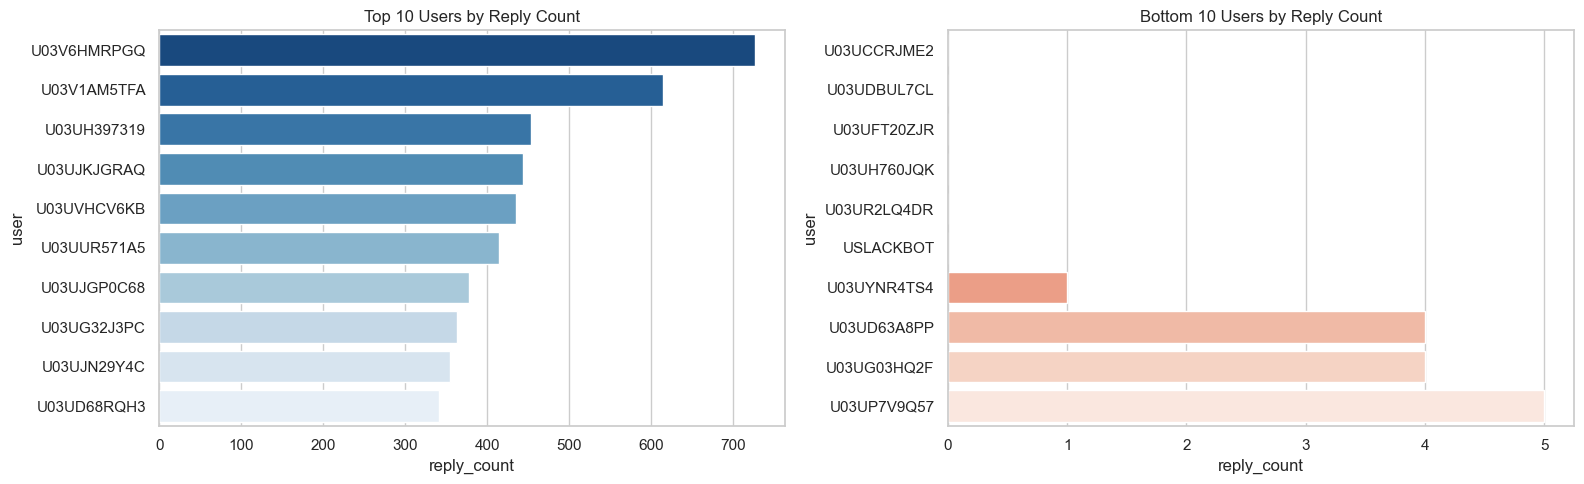

In [6]:
plot_top_bottom(df, 'reply_count', 'Reply Count')

/var/folders/9w/mmnsxrnd18bbj_zyw1pcynn40000gn/T/ipykernel_89269/1525373078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=column, y='user', ax=axes[0], palette='Blues_r')
/var/folders/9w/mmnsxrnd18bbj_zyw1pcynn40000gn/T/ipykernel_89269/1525373078.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x=column, y='user', ax=axes[1], palette='Reds_r')


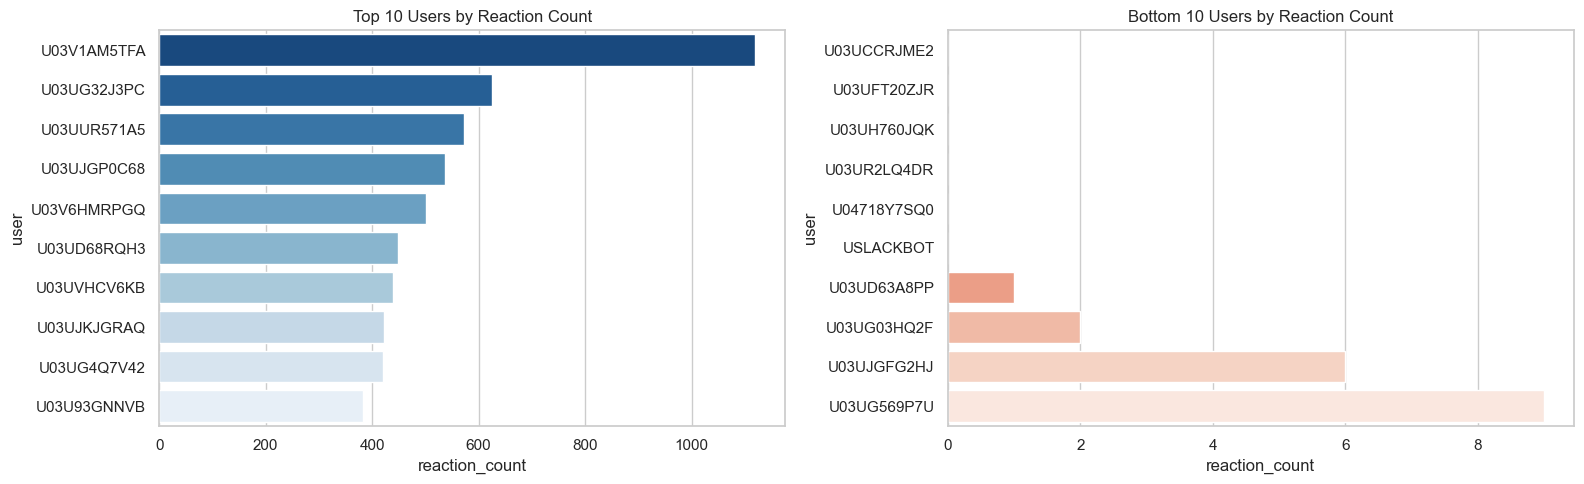

In [7]:
plot_top_bottom(df, 'reaction_count', 'Reaction Count')

/var/folders/9w/mmnsxrnd18bbj_zyw1pcynn40000gn/T/ipykernel_89269/1525373078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x=column, y='user', ax=axes[0], palette='Blues_r')
/var/folders/9w/mmnsxrnd18bbj_zyw1pcynn40000gn/T/ipykernel_89269/1525373078.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom10, x=column, y='user', ax=axes[1], palette='Reds_r')


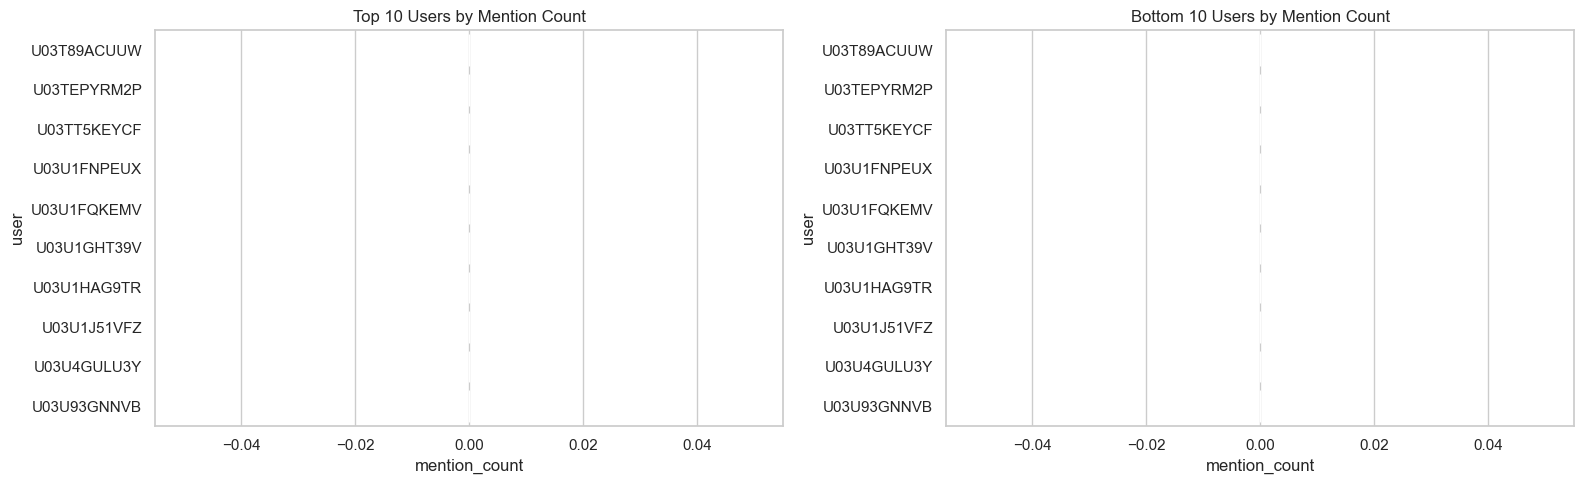

In [8]:
plot_top_bottom(df, 'mention_count', 'Mention Count')

## 4. Top 10 Messages

In [9]:
# Top 10 messages by replies
top_by_replies = df.nlargest(10, 'reply_count')[['user', 'channel', 'text', 'reply_count']]
print('Top 10 messages by replies:')
top_by_replies

Top 10 messages by replies:


,user,channel,text,reply_count
9312,U03UUP56MDF,kafka_de,<!here> i'm getting this error when i try to p...,168
18270,U03UJKJGRAQ,all-community-building,<@u03v1am5tfa> how many crushes you have?,75
11466,U03U1FQKEMV,all-community-building,first impression: people think i am older than...,63
6959,U03UD68RQH3,all-week7,1. how do i find my jupyter notebook file in m...,61
2878,U03UHB8CXDY,all-ideas,"if meta stock's decline continues like this,fa...",57
12062,U03UJKJGRAQ,all-community-building,how many here follow football so much? i think...,57
9783,U03UFV7TUTV,random,ethiopian new year loading ....,54
10296,U03UJGP0C68,random,how is this possible :grin: see the reply time,48
19045,U03V1AM5TFA,all-broadcast,hello\n1. <@u03uvhcv6kb>\n2. <@u03ug5vfn03>\n3...,45
3369,U03V785NLSU,all-week10,<@u03uur571a5> solutions to funding account an...,44


In [10]:
# Top 10 messages by reactions
top_by_reactions = df.nlargest(10, 'reaction_count')[['user', 'channel', 'text', 'reaction_count']]
print('Top 10 messages by reactions:')
top_by_reactions

Top 10 messages by reactions:


,user,channel,text,reaction_count
5621,U03TT5KEYCF,all-career-exercises,<!channel>\nthere will be no careers exercise ...,36
6714,U03TEPYRM2P,all-week9,"good morning winners, welcome to week 9 of wee...",26
15105,U03V1AM5TFA,all-community-building,*news news* *<!here>*........:drum_with_drumst...,25
6562,U03U93GNNVB,all-week9,<@u03ujgp0c68> <@u03uur571a5> <@u03v785nlsu> p...,24
19015,U03TEPYRM2P,all-broadcast,*update on week 9 activities*\n<!channel> this...,21
14000,U03V1AM5TFA,all-community-building,*guys <!here>.... make sure to come back from ...,20
17129,U03V1AM5TFA,all-community-building,*hot seat announcement! <!here>*\n_*good morni...,20
18854,U03U93GNNVB,all-broadcast,little known fact - all Joanne academy technic...,19
8136,U03TEPYRM2P,all-week6,"welcome to week6 everyone. by friday, we’ll be...",17
15910,U03UG0SFHGT,all-community-building,my reactions when am not finished the task bef...,17


In [11]:
# Top 10 messages by mentions
top_by_mentions = df.nlargest(10, 'mention_count')[['user', 'channel', 'text', 'mention_count']]
print('Top 10 messages by mentions:')
top_by_mentions

Top 10 messages by mentions:


,user,channel,text,mention_count
0,U03V61VGQG0,chang-w11,guys meeting has started,0
1,U03UAKATQ22,chang-w11,can anyone please explain to me what we are ex...,0
2,U03UH397319,chang-w11,i think the objective is to predict if the use...,0
3,U03UH397319,chang-w11,that's it based on my understanding,0
4,U03UUN8M4RX,chang-w11,<@u03uakatq22> as you could imagine we are ext...,0
5,U03UAKATQ22,chang-w11,"<@u03uun8m4rx> yes, it is clear. thank you. so...",0
6,U03UAKATQ22,chang-w11,<https://www.projectpro.io/project-use-case/bu...,0
7,U03UH397319,chang-w11,hello turors... please could you check my conn...,0
8,U03UH397319,chang-w11,<@u03ukl27b0r>,0
9,U03UKL27B0R,chang-w11,"yes, you will have to develop a custom model. ...",0


## 5. Channel Activity

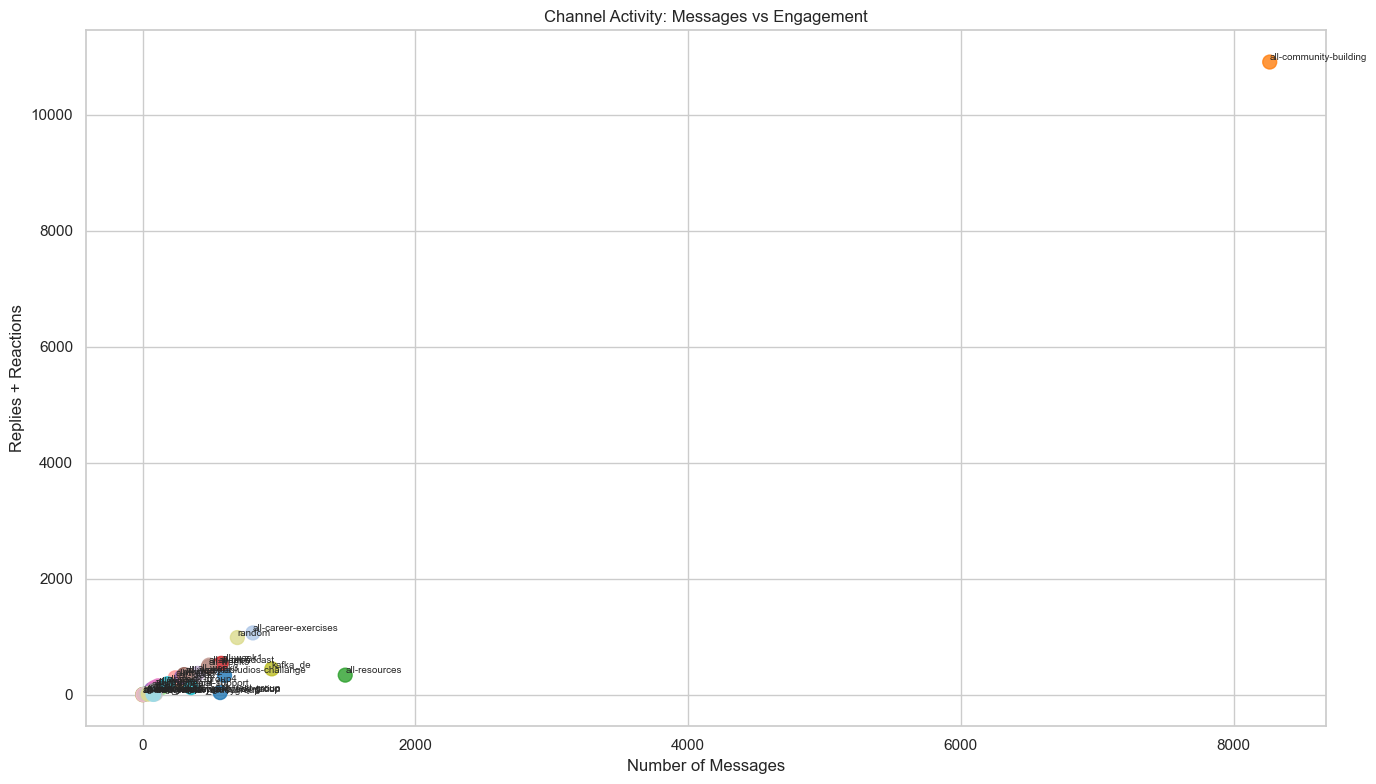

Most active channel:
                  channel  message_count  replies_plus_reactions
4  all-community-building           8264                   10908


In [12]:
channel_stats = df.groupby('channel').agg(
    message_count=('text', 'count'),
    total_replies=('reply_count', 'sum'),
    total_reactions=('reaction_count', 'sum')
).reset_index()

channel_stats['replies_plus_reactions'] = (
    channel_stats['total_replies'] + channel_stats['total_reactions']
)

plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    channel_stats['message_count'],
    channel_stats['replies_plus_reactions'],
    c=range(len(channel_stats)),
    cmap='tab20',
    s=100,
    alpha=0.8
)

for _, row in channel_stats.iterrows():
    plt.annotate(row['channel'], (row['message_count'], row['replies_plus_reactions']),
                 fontsize=7, ha='left', va='bottom')

plt.xlabel('Number of Messages')
plt.ylabel('Replies + Reactions')
plt.title('Channel Activity: Messages vs Engagement')
plt.tight_layout()
plt.show()

print('Most active channel:')
print(channel_stats.nlargest(1, 'replies_plus_reactions')[['channel', 'message_count', 'replies_plus_reactions']])

## 6. Reply Time Analysis

In [13]:
# Get messages that have at least one reply
has_replies = df[df['reply_count'] > 0].copy()

def get_first_reply_ts(replies):
    if isinstance(replies, list) and len(replies) > 0:
        return float(replies[0]['ts'])
    return None

has_replies['first_reply_ts'] = has_replies['replies'].apply(get_first_reply_ts)
has_replies = has_replies.dropna(subset=['first_reply_ts'])

has_replies['msg_ts'] = has_replies['ts'].astype(float)
has_replies['reply_time_diff_mins'] = (
    (has_replies['first_reply_ts'] - has_replies['msg_ts']) / 60
)

# Fraction replied within 5 minutes
within_5 = (has_replies['reply_time_diff_mins'] <= 5).sum()
total = len(has_replies)
print(f'Messages replied within 5 mins: {within_5}/{total} = {within_5/total:.1%}')

Messages replied within 5 mins: 1351/2021 = 66.8%


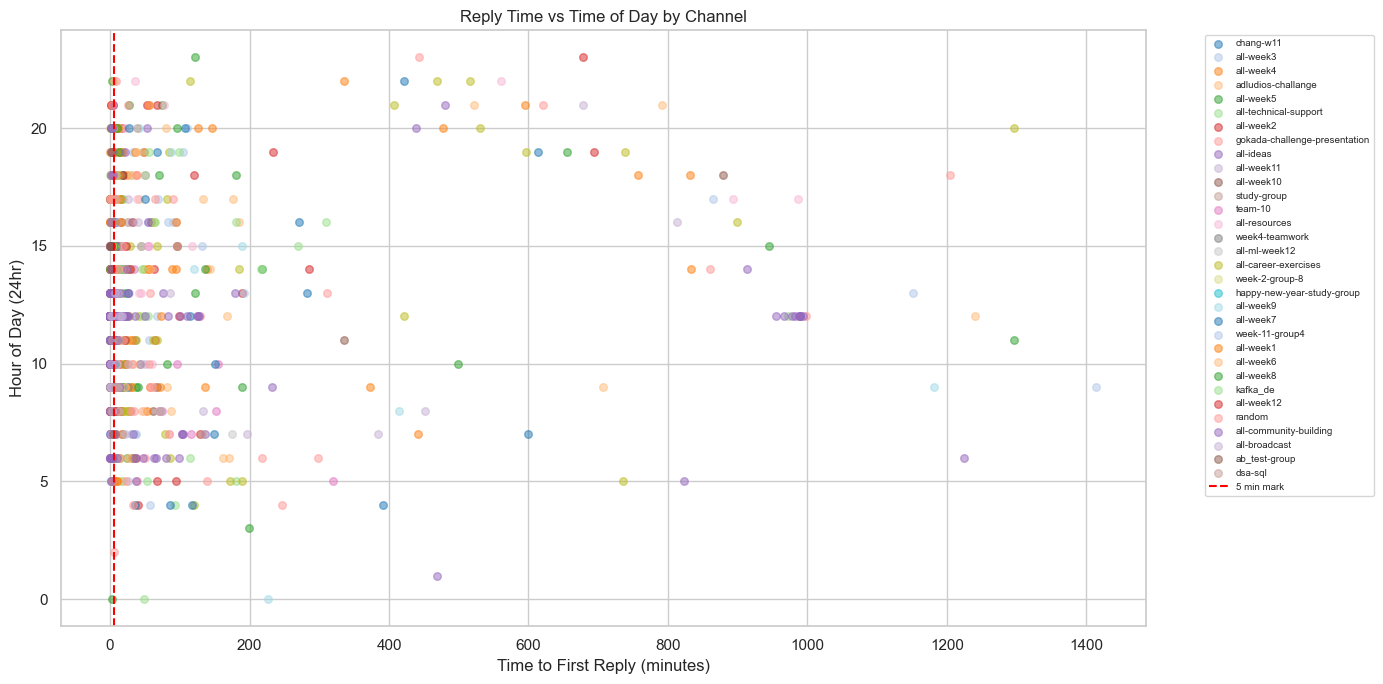

In [14]:
# Scatter plot: time diff vs time of day, colored by channel
plot_df = has_replies[has_replies['reply_time_diff_mins'] < 1440].copy()  # under 24hrs

plt.figure(figsize=(14, 7))
channels = plot_df['channel'].unique()
colors = plt.cm.tab20.colors

for i, ch in enumerate(channels):
    sub = plot_df[plot_df['channel'] == ch]
    plt.scatter(
        sub['reply_time_diff_mins'],
        sub['hour'],
        label=ch,
        color=colors[i % len(colors)],
        alpha=0.5,
        s=30
    )

plt.axvline(x=5, color='red', linestyle='--', label='5 min mark')
plt.xlabel('Time to First Reply (minutes)')
plt.ylabel('Hour of Day (24hr)')
plt.title('Reply Time vs Time of Day by Channel')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()